In [117]:
# 5.2

import numpy as np

# Getting the filename from user (67haha)
filename = input("pls enter the file name: ")
x, y = np.loadtxt(filename, unpack=True)

# Getting the arrays
# x = a[:,0]
# y = a[:,1]

# min max mean
print("The minimum for x", np.min(x))
print("The minimum for y", np.min(y))
print("The maximum for x", np.max(x))
print("The maximum for y", np.max(y))
print("The mean for x", np.mean(x))
print("The mean for y", np.mean(y))

# The new array
y_med = np.median(y)
y2 = (y - y_med)**2

print("The new list is", y2)

pls enter the file name: 67haha
The minimum for x 1.0
The minimum for y 2.0
The maximum for x 42.0
The maximum for y 37.0
The mean for x 8.9
The mean for y 9.1
The new list is [ 25.  16.   0.   0.   0.   0.   1.   1.   4. 900.]


In [118]:
# 5.6

import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Adds the list together into a bigger list so a 1D vector
print("The concatenation:", np.concatenate((a, b)))

aa = np.array([[1, 2], [3, 4]])
bb = np.array([[5, 6], [7, 8]])

# Makes the 2 by 2 matrices into a 4 by 2 so still kinda adds them
print("The concatenation:", np.concatenate((aa, bb)))

# The first one (axis=0) does what the above is doing and makes it a 4x2
# The second one adds them up by columns so the result is a 2x4
print("The concatenation:", np.concatenate((aa, bb), axis=0))
print("The concatenation:", np.concatenate((aa, bb), axis=1))
print("The concatenation:", np.concatenate((aa, bb), axis=None))

The concatenation: [1 2 3 4 5 6]
The concatenation: [[1 2]
 [3 4]
 [5 6]
 [7 8]]
The concatenation: [[1 2]
 [3 4]
 [5 6]
 [7 8]]
The concatenation: [[1 2 5 6]
 [3 4 7 8]]
The concatenation: [1 2 3 4 5 6 7 8]


/tmp/ipykernel_2731914/11282671.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  m101 = imread("m101BW.jpg")


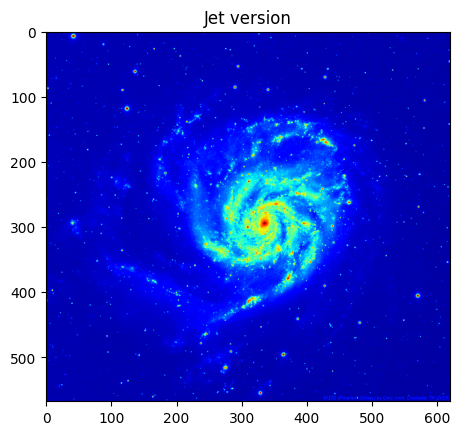

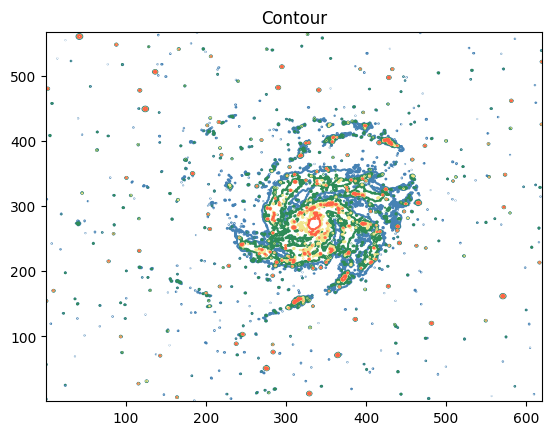

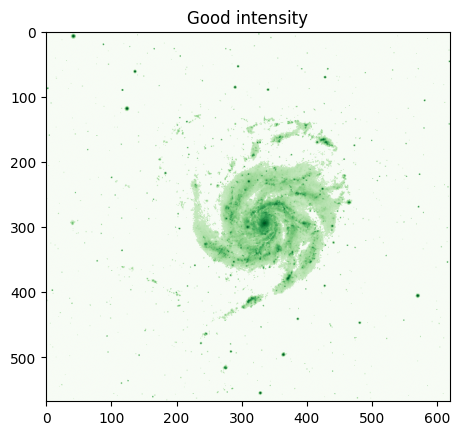

In [121]:
# 5.9

from imageio import imread
import matplotlib.pyplot as plt
import numpy as np

m101 = imread("m101BW.jpg")

plt.figure()
plt.imshow(m101, cmap='jet')
plt.title("Jet version")

plt.figure()
plt.contour(m101, levels=[75, 100, 150, 175], colors=['steelblue', 'seagreen', 'khaki', 'tomato'], origin='upper')
plt.title("Contour")


plt.figure()
intensity = np.percentile(m101, 90)
gooddata = np.where(m101 > intensity, m101, 0)
plt.imshow(gooddata, cmap='Greens')
plt.title("Good intensity")

plt.show()


[0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]


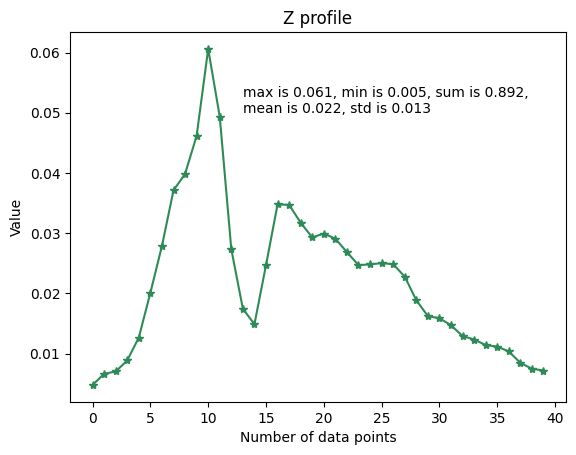

In [66]:
# 5.10

import numpy as np
import matplotlib.pyplot as plt

# Getting the data to be shaped and the z profile line
data = np.loadtxt('ngc6946')
reshaped = data.reshape(40, 50, 70)

print(reshaped[:,25,35])

Max = np.max(reshaped[:,25,35])
Min = np.min(reshaped[:,25,35])
Sum = np.sum(reshaped[:,25,35])
Mean = np.mean(reshaped[:,25,35])
Std = np.std(reshaped[:,25,35])

plt.figure()
plt.plot(reshaped[:,25,35], marker='*', color="seagreen")
plt.title("Z profile")
plt.xlabel("Number of data points")
plt.ylabel("Value")
plt.text(13, 0.05, f"max is {Max:.3f}, min is {Min:.3f}, sum is {Sum:.3f},\nmean is {Mean:.3f}, std is {Std:.3f}",  fontsize=10)

plt.show()

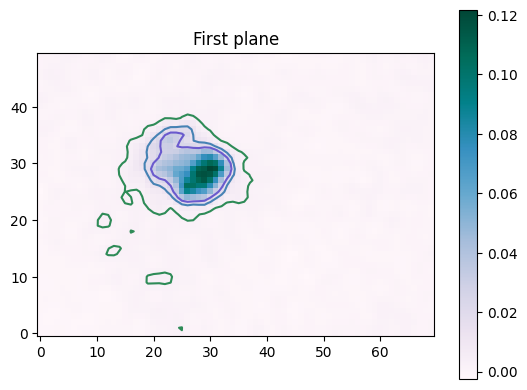

In [80]:
# 5.11

import numpy as np
import matplotlib.pyplot as plt

# Extracting the first plane out of the data
data = np.loadtxt('ngc6946')
reshaped = data.reshape(40, 50, 70)
plane = reshaped[0,:,:]

mean = np.mean(plane)
std = np.std(plane)

plt.figure()
plt.imshow(plane, cmap='PuBuGn', origin='lower')
plt.colorbar()
plt.contour(plane, levels=[mean, mean+std, mean+(2*std)], colors=['seagreen', 'steelblue', 'slateblue'])
plt.title("First plane")

plt.show()

In [98]:
# 5.12

import scipy.constants

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5                # Calcium H line in rest frame
    c = scipy.constants.c / 1000  # In km/s
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
        
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
        
    def velocity(self):
        return self.c * self.redshift()
        
a = Galaxy("Meowmoew", calciumHline = 4000)

print(f"The velocity for {a.name} galaxy is {a.velocity():.2f} km/s")

The velocity for Meowmoew galaxy is 2360.87 km/s


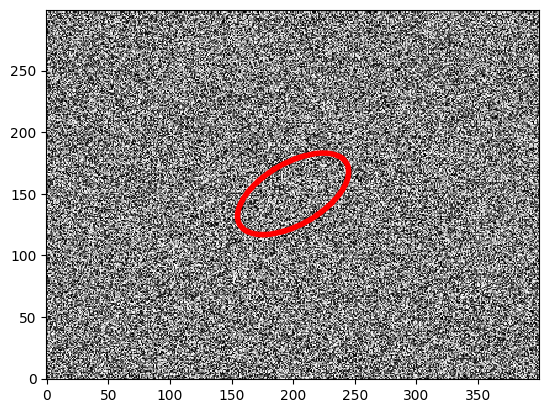

In [116]:
# 5.13 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

figure()

ax = plt.gca()

plt.imshow(data, interpolation='none', origin="lower", cmap='gray')
ellipse = Ellipse((200,150), 100, 50, angle=30, fc='None', ec='r', lw=4)

ax.add_patch(ellipse)

show()